TO DO: Create a Python Notebook that merges the data and creates all of the analysis that is in the excel files. I need to use pandas, numpy and pyplot to create charts after I merge the data together. 

In [2]:
import pandas as pd
from collections import defaultdict
from math import floor

Support Functions that will be used later

In [3]:
'''
Support Functions
'''

def blank():
    return 0

def calculate_more_expensive_winner(row):
    if row["Home_GDP"]==row["Away_GDP"] or row["home_score"]==row["away_score"]:
        return 0
    elif row["Home_GDP"]>row["Away_GDP"]:
        if row["home_score"]>row["away_score"]:
            return 1
        else:
            return -1
    elif row["Home_GDP"]<row["Away_GDP"]:
        if row["home_score"]<row["away_score"]:
            return 1
        else:
            return -1
    return 0

def calculate_significantly_wealthier_team(row):
    if 1.0*row["Home_GDP"]>=2.0*row["Away_GDP"]:
        return True
    if 2.0*row["Home_GDP"]<=1.0*row["Away_GDP"]:
        return True
    return False

In [4]:
#Load and Prepare Data

gdp_df=pd.read_excel("data/country-gdp-by-year.xlsx")
world_cup_df=pd.read_excel("data/world-cup-results.xlsx")
world_cup_df["year"]=world_cup_df["date"].dt.year
world_cup_df["decade"]=(world_cup_df["year"]//10)*10


In [5]:
#Load Country Year GDPs to dictionary
gdp_dict=defaultdict(blank)
for index,row in gdp_df.iterrows():
    dictionary_key=f"{row['Country Name']}-{row['Year']}"
    if not pd.isna(row["GDP"]):
        gdp_dict[dictionary_key]=floor(row["GDP"])

In [6]:
#Attach Country Year GDPs to World Cup Match Data
world_cup_df["Home_GDP"]=-1
world_cup_df["Away_GDP"]=-1

for index,row in world_cup_df.iterrows():
    home_key=f"{row['home_team']}-{row['year']}"
    world_cup_df.at[index,"Home_GDP"]=gdp_dict[home_key]
    away_key=f"{row['away_team']}-{row['year']}"
    world_cup_df.at[index,"Away_GDP"]=gdp_dict[away_key]

In [7]:
#Remove all rows where the Home GDP or Away GDP are na, -1 or 0

world_cup_df=world_cup_df[world_cup_df["Home_GDP"].notna()]
world_cup_df=world_cup_df[world_cup_df["Away_GDP"].notna()]
world_cup_df=world_cup_df[world_cup_df["Home_GDP"]!=-1]
world_cup_df=world_cup_df[world_cup_df["Away_GDP"]!=-1]
world_cup_df=world_cup_df[world_cup_df["Home_GDP"]!=0]
world_cup_df=world_cup_df[world_cup_df["Away_GDP"]!=0]

print(world_cup_df["Home_GDP"].describe())

count    6.410000e+03
mean     4.565575e+11
std      1.671436e+12
min      8.091320e+07
25%      1.073250e+10
50%      4.573513e+10
75%      2.521929e+11
max      2.560485e+13
Name: Home_GDP, dtype: float64


In [8]:
#Calculate whether one team was significantly wealthier than another

world_cup_df["Significantly_Wealthier_Team"]=world_cup_df.apply(calculate_significantly_wealthier_team,axis=1)

#Calculate whether the wealthier team won

world_cup_df["Wealthier_Winner"]=world_cup_df.apply(calculate_more_expensive_winner,axis=1)
print(world_cup_df["Wealthier_Winner"].describe())
print(world_cup_df.head())
world_cup_df.to_excel("merged_results/world-cup-results-gdp.xlsx")

count    6410.000000
mean        0.297504
std         0.832675
min        -1.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: Wealthier_Winner, dtype: float64
          date   home_team   away_team  home_score  away_score  \
347 1960-08-21  Costa Rica   Guatemala         3.0         2.0   
348 1960-08-28       Ghana     Nigeria         4.0         1.0   
349 1960-08-28   Guatemala  Costa Rica         4.0         4.0   
350 1960-09-04    Honduras  Costa Rica         2.0         1.0   
351 1960-09-10     Nigeria       Ghana         2.0         2.0   

                       tournament            city     country  neutral  year  \
347  FIFA World Cup qualification       San Jos√©  Costa Rica    False  1960   
348  FIFA World Cup qualification           Accra       Ghana    False  1960   
349  FIFA World Cup qualification  Guatemala City   Guatemala    False  1960   
350  FIFA World Cup qualification     Tegucigalpa    Honduras    False  1960

[1960 1970 1980 1990 2000 2010 2020]


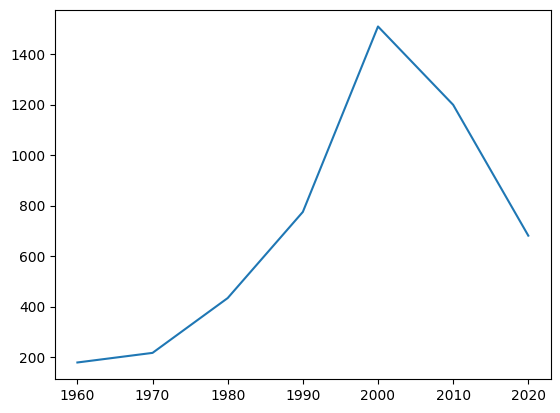

In [14]:
import matplotlib.pyplot as plt

#Simple count tracking how many games were played each decade by wealthier teams
wealthier_df=world_cup_df[world_cup_df["Significantly_Wealthier_Team"]==True]
decades=wealthier_df["decade"].unique()
print(decades)
decade_count=wealthier_df.groupby("decade").size()
plt.plot(decades,decade_count)
plt.show()


[1960 1970 1980 1990 2000 2010 2020]


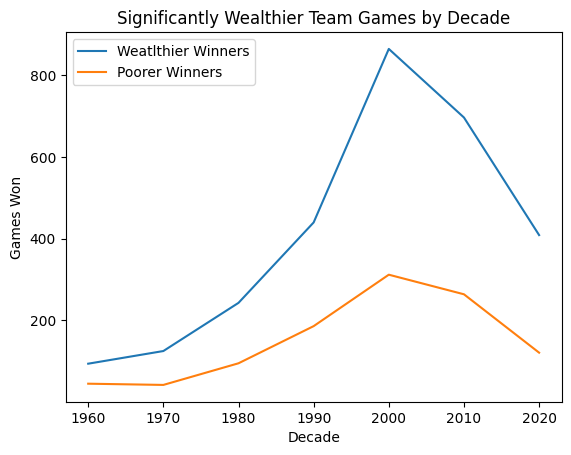

In [15]:
#track how many games were won by wealthier teams and how many were won by poorer teams

wealthier_winner_df=wealthier_df[wealthier_df["Wealthier_Winner"]==1]
tie_df=wealthier_df[wealthier_df["Wealthier_Winner"]==0]
poorer_winner_df=wealthier_df[wealthier_df["Wealthier_Winner"]==-1]

decades=wealthier_df["decade"].unique()
print(decades)
wealthier_winner_count=(wealthier_winner_df.groupby("decade").size())
tie_count=(tie_df.groupby("decade").size())
poorer_winner_count=(poorer_winner_df.groupby("decade").size())
plt.plot(decades,wealthier_winner_count,label="Weatlthier Winners")
plt.plot(decades,poorer_winner_count,label="Poorer Winners")
plt.xlabel("Decade")
plt.ylabel("Games Won")
plt.title("Significantly Wealthier Team Games by Decade")
plt.legend()  # Displays the labels assigned above
plt.show()

In [22]:

# Define a standard function
def to_percent(score):
    if score >= 60:
        return "Pass"
    return "Fail"

#100% Bar Chart for games by decade
print(type(wealthier_winner_count))

wealthier_winner_percent=100*wealthier_winner_count/decade_count
tie_percent=100*tie_count/decade_count
poorer_winner_percent=100*poorer_winner_count/decade_count


print(wealthier_winner_count)
print(tie_count)
print(poorer_winner_count)

<class 'pandas.core.series.Series'>
decade
1960     94
1970    125
1980    243
1990    440
2000    865
2010    697
2020    409
dtype: int64
decade
1960     40
1970     50
1980     96
1990    149
2000    332
2010    238
2020    151
dtype: int64
decade
1960     45
1970     42
1980     95
1990    186
2000    312
2010    264
2020    121
dtype: int64


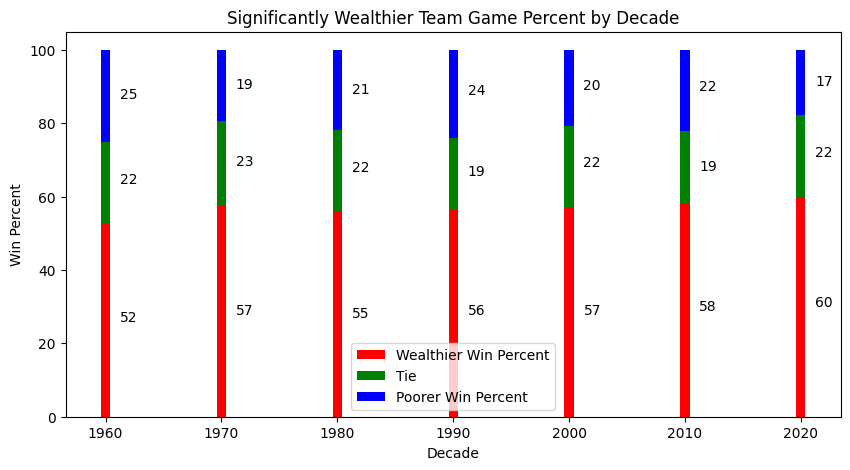

In [35]:
# Function to place labels at the center of each bar
def add_labels(x, y,y_offsets=None):
    if y_offsets is not None:
        for x_val, y_val,y_offset in zip(x, y,y_offsets):
            plt.text(x_val+2, y_offset+(y_val//2), floor(y_val), ha='center')  # Placing text at half the bar height
    else:
        for x_val, y_val in zip(x, y):
            plt.text(x_val+2, (y_val//2), floor(y_val), ha='center')  # Placing text at half the bar height

# Setting figure size
plt.figure(figsize=(10, 5))

plt.bar(decades, wealthier_winner_percent, color='r',label="Wealthier Win Percent")
add_labels(decades,wealthier_winner_percent)

plt.bar(decades, tie_percent, bottom=wealthier_winner_percent, color='g',label="Tie")
add_labels(decades,tie_percent,wealthier_winner_percent)

tie_and_wealthier_win_percent=wealthier_winner_percent+tie_percent
plt.bar(decades, poorer_winner_percent, bottom=tie_and_wealthier_win_percent, color='b',label="Poorer Win Percent")
add_labels(decades,poorer_winner_percent,tie_percent+wealthier_winner_percent)

plt.title("Significantly Wealthier Team Game Percent by Decade")
plt.xlabel("Decade")
plt.ylabel("Win Percent")
plt.legend()
plt.show()